In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 7.3 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [4]:
results = model.train(
    data="/content/drive/MyDrive/fire_dataset/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    project="Fire_Project",
    name="Fire_Detection",
    device=0
)

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/fire_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Fire_Detection, nbs=64, nms=N

In [3]:
from ultralytics import YOLO
model = YOLO('/content/runs/detect/Fire_Project/Fire_Detection/weights/best.pt')

# Run validation
metrics = model.val()

# Print key accuracy metrics
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.3±0.1 ms, read: 22.0±9.2 MB/s, size: 24.6 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/fire_dataset/valid/labels.cache... 16 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 16/16 2.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.1it/s 0.5s
                   all         16         19       0.75      0.579       0.59      0.311
Speed: 0.5ms preprocess, 5.1ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/detect/val
mAP50: 0.590163464441564
mAP50-95: 0.3112602790503642



image 1/1 /content/fire_test1.jpg: 640x640 1 fire, 7.2ms
Speed: 2.2ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Class: fire | Score: 0.6797 | Box (xyxy): [185.01898193359375, 17.676536560058594, 333.3466491699219, 212.0002899169922]


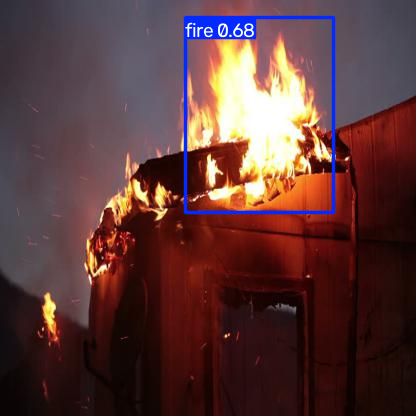

In [13]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

model = YOLO('/content/runs/detect/Fire_Project/Fire_Detection/weights/best.pt')

results = model.predict(source='/content/fire_test1.jpg', conf=0.25)

for result in results:
    boxes = result.boxes

    for box in boxes:
        xyxy = box.xyxy[0].tolist()

        score = box.conf[0].item()

        class_id = int(box.cls[0].item())
        class_name = model.names[class_id]

        print(f"Class: {class_name} | Score: {score:.4f} | Box (xyxy): {xyxy}")


annotated_frame = results[0].plot()

cv2_imshow(annotated_frame)